In [4]:
# ======================================
# 1️⃣ Import Libraries
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE


In [5]:
# ======================================
# 2️⃣ Load Dataset
# ======================================

df = pd.read_csv(r"C:\Users\gaura\Downloads\archive\insurance_data.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 38)


In [6]:
# ======================================
# 3️⃣ Drop Irrelevant Columns
# ======================================

drop_cols = [
    'TXN_DATE_TIME', 'TRANSACTION_ID', 'CUSTOMER_ID',
    'POLICY_NUMBER', 'CUSTOMER_NAME',
    'ADDRESS_LINE1', 'ADDRESS_LINE2',
    'SSN', 'ROUTING_NUMBER', 'ACCT_NUMBER'
]

df = df.drop(columns=drop_cols)

In [7]:
# ======================================
# 4️⃣ Target Variable Setup
# ======================================

target_column = "CLAIM_STATUS"

# Convert target to numeric
le = LabelEncoder()
df[target_column] = le.fit_transform(df[target_column])

X = df.drop(target_column, axis=1)
y = df[target_column]


In [8]:
# ======================================
# 5️⃣ Convert Categorical Features
# ======================================

X = pd.get_dummies(X, drop_first=True)

In [9]:
# ======================================
# 6️⃣ Train-Test Split
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nBefore SMOTE:")
print(pd.Series(y_train).value_counts())



Before SMOTE:
CLAIM_STATUS
0    7598
1     402
Name: count, dtype: int64


In [10]:
# ======================================
# 7️⃣ Apply SMOTE (Fix Imbalance)
# ======================================

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())


After SMOTE:
CLAIM_STATUS
0    7598
1    7598
Name: count, dtype: int64


In [11]:
# ======================================
# 8️⃣ Feature Scaling (Important for SVM)
# ======================================

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
# ======================================
# 9️⃣ Initialize SVM Model
# ======================================

svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

In [13]:
# ======================================
# 🔟 Train Model
# ======================================

svc.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
# ======================================
# 1️⃣1️⃣ Predictions
# ======================================

y_pred = svc.predict(X_test)

In [15]:
# ======================================
# 1️⃣2️⃣ Accuracy
# ======================================

train_acc = accuracy_score(y_train, svc.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print("\nTraining Accuracy:", train_acc)
print("Test Accuracy:", test_acc)



Training Accuracy: 0.9948670702816531
Test Accuracy: 0.9115


In [16]:
# ======================================
# 1️⃣3️⃣ Confusion Matrix
# ======================================

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)



Confusion Matrix:
 [[1820   79]
 [  98    3]]


In [17]:
# ======================================
# 1️⃣4️⃣ Classification Report
# ======================================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))



Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1899
           1       0.04      0.03      0.03       101

    accuracy                           0.91      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.90      0.91      0.91      2000



In [18]:
# ======================================
# 1️⃣5️⃣ ROC-AUC Score
# ======================================

y_prob = svc.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:", roc_score)



ROC-AUC Score: 0.49570644268218295


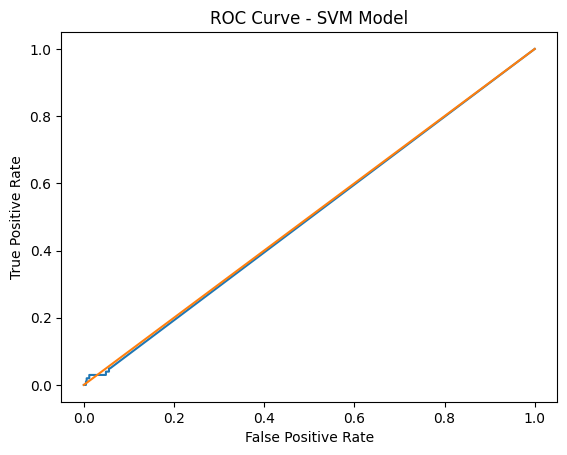

In [19]:
# ======================================
# 1️⃣6️⃣ ROC Curve
# ======================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM Model")
plt.show()